In [1]:
import imageio
import matplotlib.pyplot as plt
import numpy as np
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
import pandas as pd

# 5.a

C:\Users\JohnG\AppData\Local\Temp\ipykernel_9584\714591958.py:4: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image_jeorge = imageio.imread(image_path)


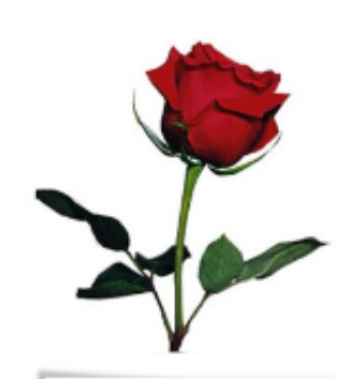

In [3]:
# Read the image from the Images folder
#image_path = 'Images_set/14325899679_179347cec0_b.jpg'
image_path = "Images/rosa.jpg" 
image_jeorge = imageio.imread(image_path) 

# Display the loaded image
plt.imshow(image_jeorge)
plt.axis('off')  # Hide the axes
plt.show()


In [4]:
# In theory, better to use this and explainplain

import numpy as np
import gurobipy as gp
from gurobipy import GRB
from numba import njit
from scipy.ndimage import zoom

def resize_image_optimized_hybrid(image, new_size, optimization_threshold=20, block_size=32):
    """
    Optimized version that uses:
    - Default interpolation for uniform areas
    - Optimization only for regions with high variation
    - Block processing and parallelization
    
    Args:
        image: Input image (numpy array)
        new_size: Desired size (x, y)
        optimization_threshold: Variation threshold to apply optimization
        block_size: Block size for processing
        
    Returns:
        Resized image
    """
    x1, y1, _ = image.shape
    x2, y2 = new_size
    resized_image = np.zeros((x2, y2, 3), dtype=np.uint8)
    
    # First apply basic interpolation to the entire image
    zoom_factors = (x2/x1, y2/y1, 1)
    interpolated = zoom(image, zoom_factors, order=1, mode='mirror')
    
    # Only optimize areas with high variation
    for c in range(3):
        channel = image[:, :, c]
        interp_channel = interpolated[:, :, c]
        
        # Calculate gradient to detect edges
        grad = np.abs(np.gradient(interp_channel))
        edge_mask = (grad[0] + grad[1]) > optimization_threshold
        
        # Process blocks only where there are edges
        for i in range(0, x2, block_size):
            for j in range(0, y2, block_size):
                i_end = min(i + block_size, x2)
                j_end = min(j + block_size, y2)
                
                # Only optimize if there is enough variation in the block
                block_mask = edge_mask[i:i_end, j:j_end]
                if np.mean(block_mask) < 0.2:  # Less than 20% of pixels with edges
                    resized_image[i:i_end, j:j_end, c] = interp_channel[i:i_end, j:j_end]
                    continue
                
                # Optimization only for this block
                optimized_block = optimize_block(
                    channel, 
                    (i, i_end), 
                    (j, j_end), 
                    (x1, y1), 
                    (x2, y2))
                
                resized_image[i:i_end, j:j_end, c] = optimized_block
    
    return resized_image

@njit
def get_neighborhood_values(channel, x, y, x1, y1):
    """Gets neighboring values with edge handling."""
    neighbors = np.zeros(8)
    positions = [
        (x-1, y-1), (x-1, y), (x-1, y+1),
        (x, y-1),             (x, y+1),
        (x+1, y-1), (x+1, y), (x+1, y+1)
    ]
    
    for k, (nx, ny) in enumerate(positions):
        nx = max(0, min(nx, x1-1))
        ny = max(0, min(ny, y1-1))
        neighbors[k] = channel[nx, ny]
    
    return neighbors

def optimize_block(channel, x_range, y_range, orig_size, new_size):
    """Optimizes a single block of the image."""
    x1, y1 = orig_size
    x2, y2 = new_size
    i_start, i_end = x_range
    j_start, j_end = y_range
    
    scale_x = x1 / x2
    scale_y = y1 / y2
    
    model = gp.Model()
    model.setParam('OutputFlag', 0)
    model.setParam('Method', 2)  # Use barrier method (better for convex problems)
    
    # Variables and constraints for the entire block
    optimized_values = np.zeros((i_end-i_start, j_end-j_start))
    
    for ii in range(i_start, i_end):
        for jj in range(j_start, j_end):
            # Coordinates in the original image
            x = int(ii * scale_x)
            y = int(jj * scale_y)
            
            # Get neighborhood
            neighbors = get_neighborhood_values(channel, x, y, x1, y1)
            
            # Create variables
            weights = model.addVars(8, lb=0, ub=1, name=f"w_{ii}_{jj}")
            target = model.addVar(lb=0, ub=255, name=f"t_{ii}_{jj}")
            
            # Constraints
            model.addConstr(weights.sum() == 1, f"sum_w_{ii}_{jj}")
            model.addConstr(target == gp.quicksum(weights[k]*neighbors[k] for k in range(8)), 
                          f"target_{ii}_{jj}")
            
            # Objective function (smoothing)
            model.setObjective(
                gp.quicksum((target - neighbors[k])**2 for k in range(8)), 
                GRB.MINIMIZE)
            
            # Solve
            model.optimize()
            
            optimized_values[ii-i_start, jj-j_start] = target.X
    
    return optimized_values.astype(np.uint8)

In [5]:
result = resize_image_optimized_hybrid(image_jeorge, (50, 50), 
                                     optimization_threshold=15, 
                                     block_size=16)


Set parameter Username
Academic license - for non-commercial use only - expires 2025-08-22


# 5.b

In [7]:
# # Load test image
original_image = image_jeorge  # Ensure the correct image is loaded
new_size = (100, 100)  # New resolution
resized_image = result  # resize_image_lp_optimized(original_image, new_size, block_size=10)


In [8]:
import os
from PIL import Image


output_folder = 'resized'
os.makedirs(output_folder, exist_ok=True)

def save_image_with_unique_name(image_array, base_name, folder):

  
    counter = 1
    file_name = f"{base_name}.png"
    while os.path.exists(os.path.join(folder, file_name)):
        file_name = f"{base_name}{counter}.png"
        counter += 1
    image = Image.fromarray(image_array)
    image.save(os.path.join(folder, file_name))


save_image_with_unique_name(original_image, "original", output_folder)
save_image_with_unique_name(resized_image, "resized", output_folder)


In [9]:
def calculate_average_vector(image):
    return np.mean(image, axis=(0, 1))

# Ejemplo de uso
average_vector = calculate_average_vector(image_jeorge)
print("Average vector (R, G, B):", average_vector)

Average vector (R, G, B): [223.56236413 215.15265399 213.41070652]


In [10]:
import os
from PIL import Image

def load_images_and_vectors(folder_path):
    """
    Loads images from a folder and calculates their average vectors.

    Args:
        folder_path (str): Path to the folder containing the images.

    Returns:
        list: List of tuples (image, average_vector).
    """
    images_and_vectors = []
    for filename in os.listdir(folder_path):
        if filename.endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(folder_path, filename)
            img = Image.open(img_path).convert('RGB')
            img_array = np.array(img)
            avg_vector = calculate_average_vector(img_array)
            images_and_vectors.append((img, avg_vector))
    return images_and_vectors


In [11]:

images_and_vectors = load_images_and_vectors('Images_set')


C:\Users\JohnG\AppData\Local\Temp\ipykernel_9584\284748618.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, 2, figsize=(10, 3))


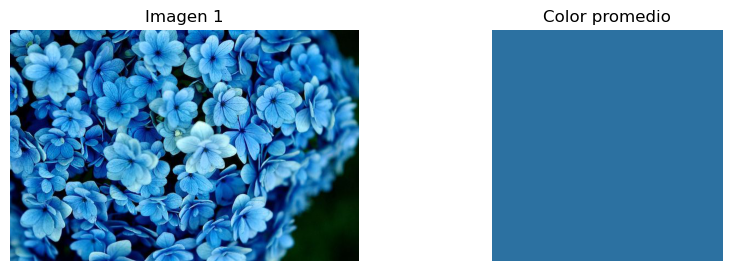

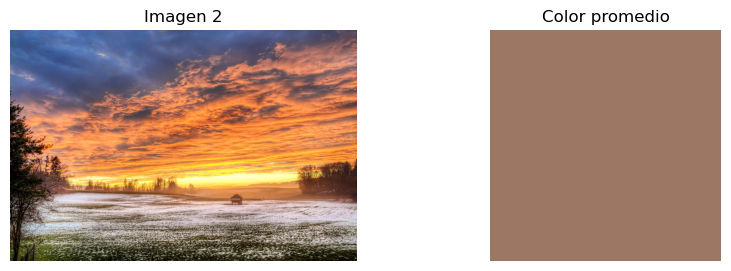

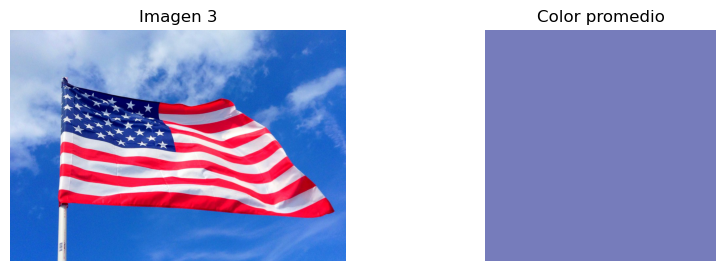

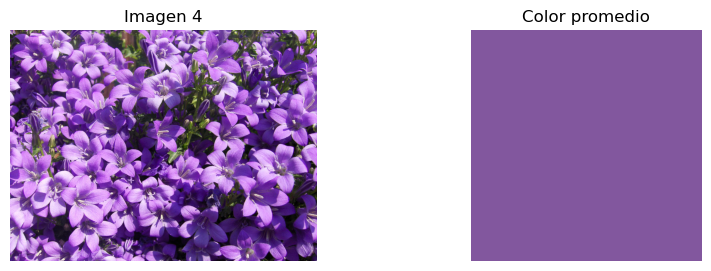

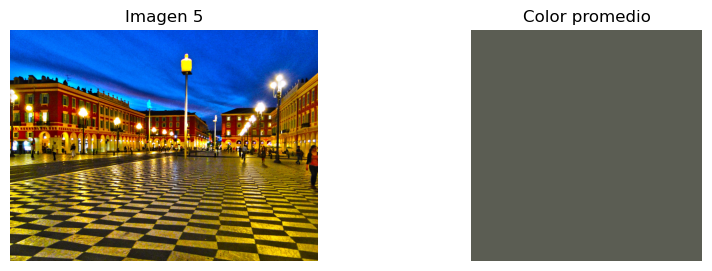

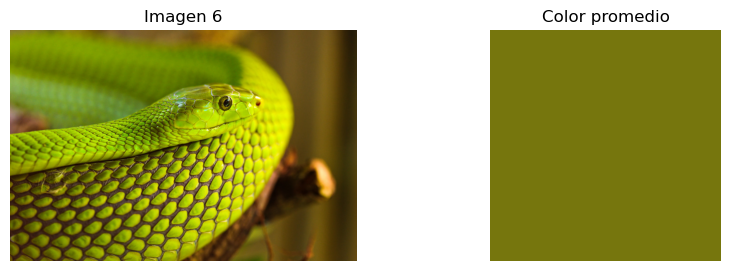

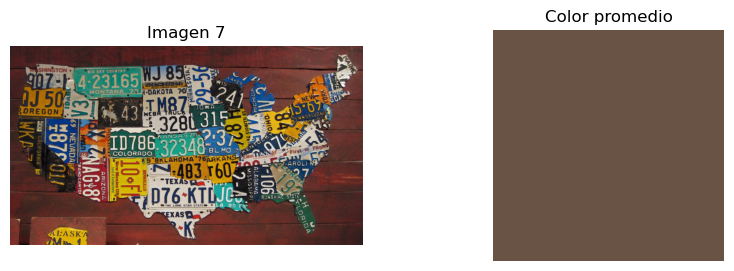

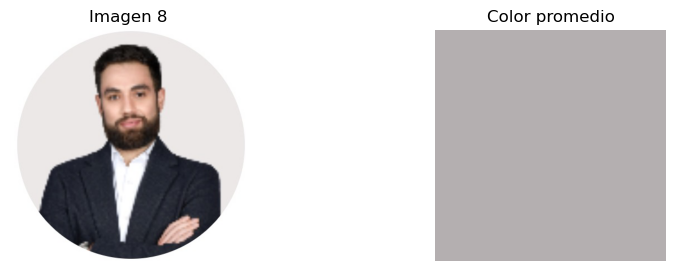

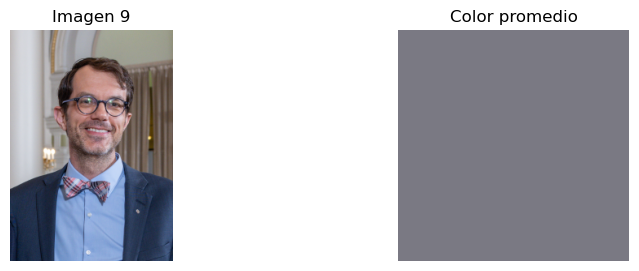

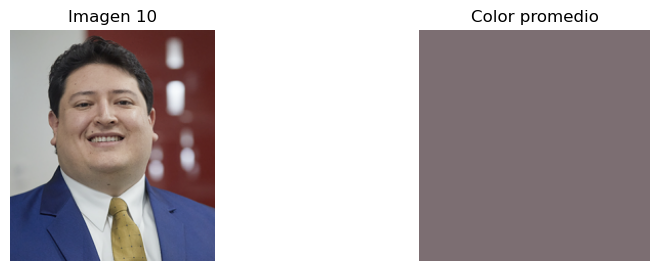

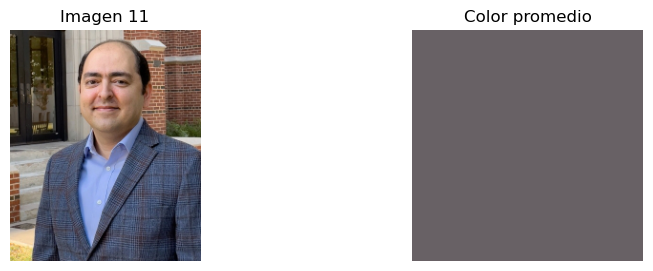

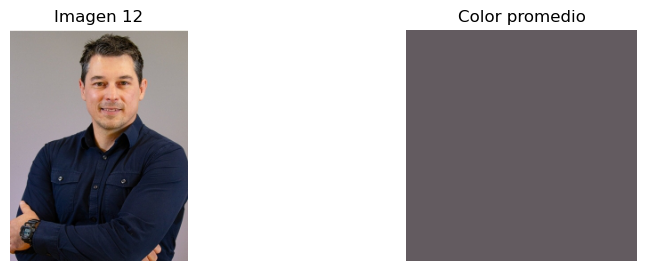

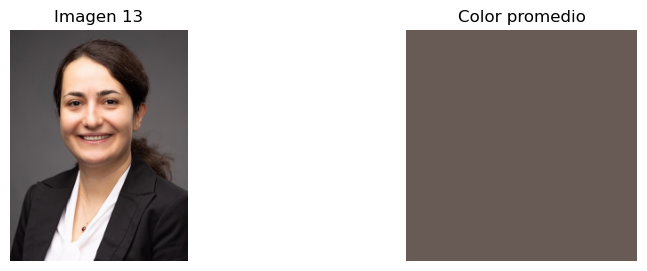

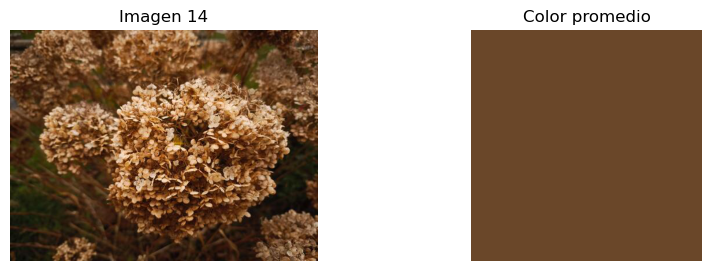

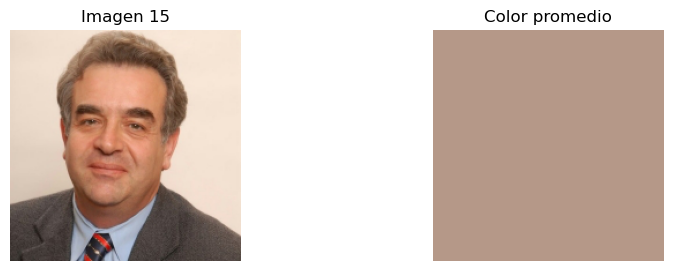

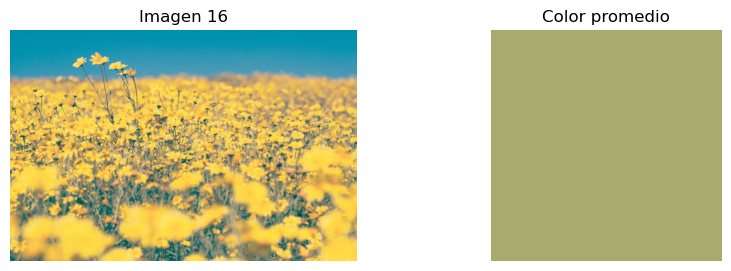

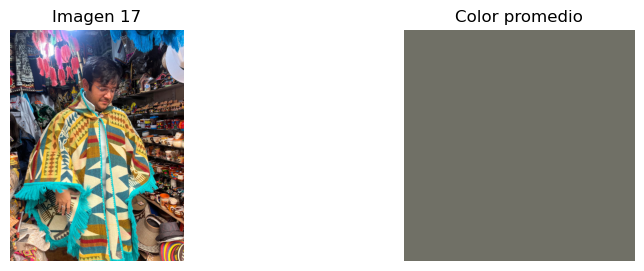

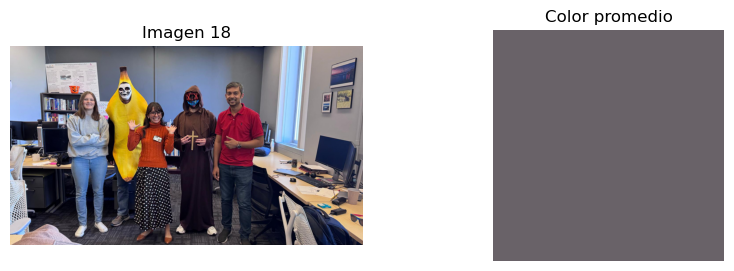

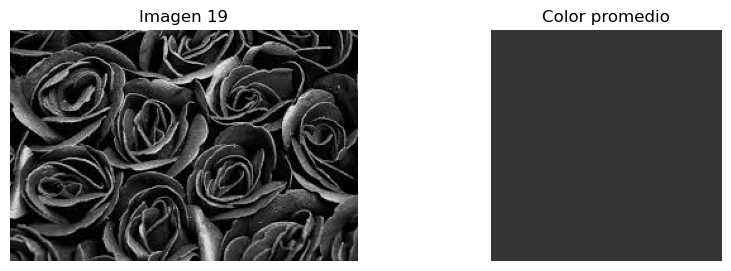

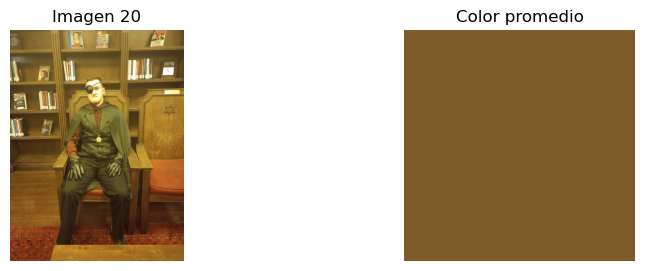

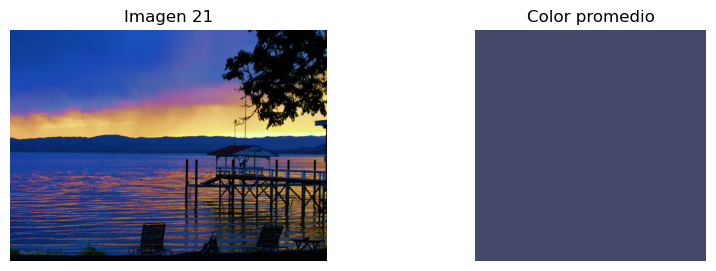

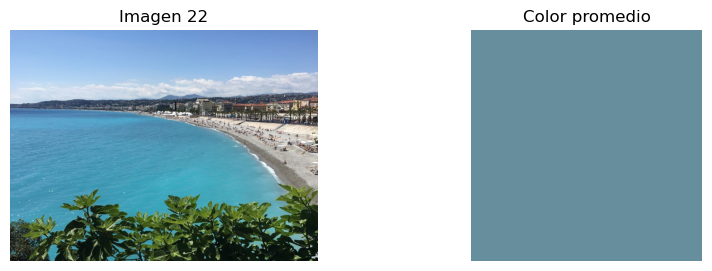

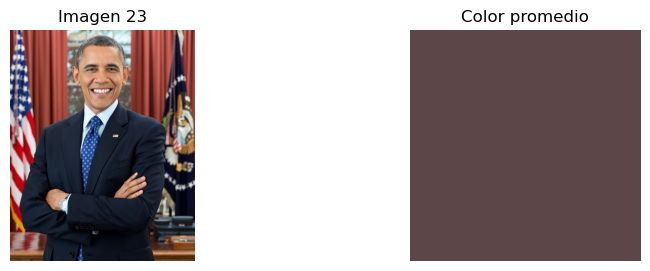

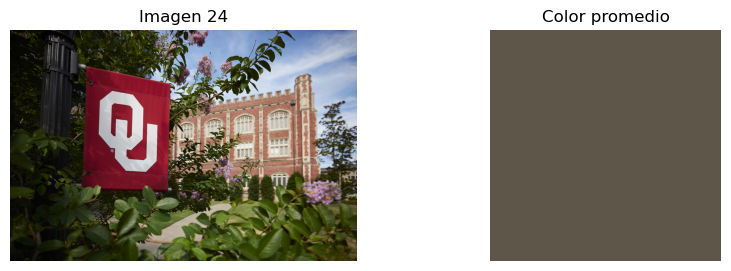

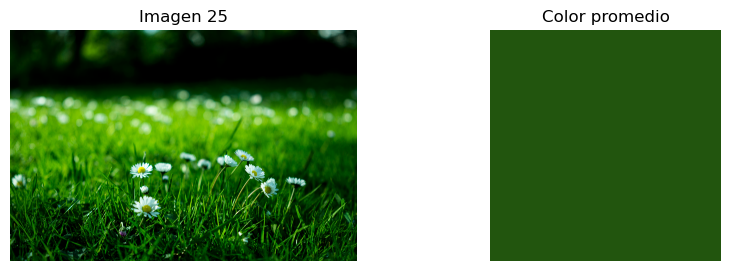

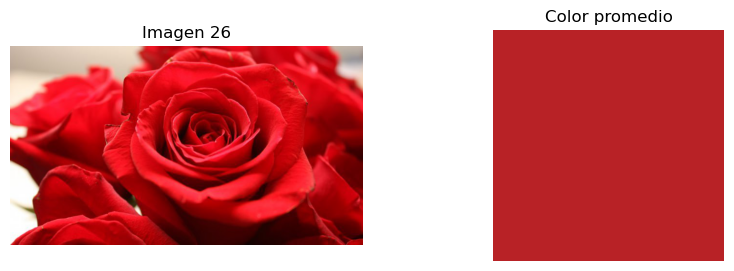

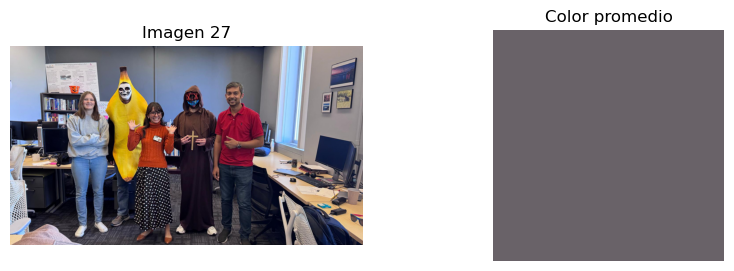

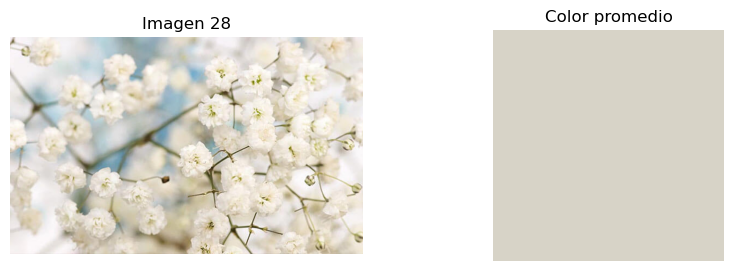

In [12]:
# Mostrar todas las imágenes, sus vectores promedio y un cuadrado con el color promedio
for i, (img, vector) in enumerate(images_and_vectors):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))

    # Mostrar la imagen original
    axes[0].imshow(img)
    axes[0].axis('off')
    axes[0].set_title(f"Imagen {i + 1}")

    # Crear un cuadrado con el color promedio
    color_square = np.ones((50, 50, 3), dtype=np.uint8) * vector.astype(np.uint8)
    axes[1].imshow(color_square / 255)  # Normalizar a rango [0, 1] para matplotlib
    axes[1].axis('off')
    axes[1].set_title(f"Color promedio")

    # plt.show()


In [13]:
def create_optimized_mosaic(target_image, images_and_vectors, mosaic_size=(25, 25), time_limit=60, lambda_reg=0.1):
    """
    Creates a globally optimized mosaic based on the given parameters.
    
    Args:
        target_image: Target image as a numpy array (RGBA or RGB)
        images_and_vectors: List of tuples (PIL_image, average_vector)
        mosaic_size: Mosaic size (rows, columns)
        time_limit: Time limit for optimization in seconds
        lambda_reg: Weight of the regularization term for diversity
        
    Returns:
        Resulting mosaic image (PIL Image)
    """
    # Convert target image to RGB if it is RGBA
    if target_image.shape[2] == 4:
        target_array = target_image[:, :, :3]  # Take only RGB channels
    else:
        target_array = target_image
    
    rows, cols = mosaic_size
    img_height, img_width = target_array.shape[:2]
    cell_height = img_height // rows
    cell_width = img_width // cols
    
    # Check for valid sizes
    if cell_height == 0 or cell_width == 0:
        raise ValueError("The mosaic size is too large for the original image")
    
    # Preprocessing: calculate target vectors for each cell
    target_vectors = []
    for i in range(rows):
        for j in range(cols):
            y_start, y_end = i * cell_height, (i + 1) * cell_height
            x_start, x_end = j * cell_width, (j + 1) * cell_width
            cell = target_array[y_start:y_end, x_start:x_end]
            target_vectors.append(calculate_average_vector(cell))
    
    # Prepare data for available images
    image_vectors = [vec for _, vec in images_and_vectors]
    num_images = len(images_and_vectors)
    num_cells = rows * cols
    
    # Create optimization model
    model = gp.Model("PhotoMosaic")
    model.setParam('OutputFlag', 0)
    model.setParam('TimeLimit', time_limit)
    
    # Decision variables: x[i,j] = 1 if image j is used in cell i
    x = model.addVars(num_cells, num_images, vtype=GRB.BINARY, name="x")
    
    # Constraint: each cell must have exactly one image
    for i in range(num_cells):
        model.addConstr(gp.quicksum(x[i, j] for j in range(num_images)) == 1)
    
    # Objective function: minimize total color distance
    obj = gp.QuadExpr()
    for i in range(num_cells):
        target_vec = target_vectors[i]
        for j in range(num_images):
            img_vec = image_vectors[j]
            diff = target_vec - img_vec
            distance = np.sum(diff**2)  # Squared Euclidean distance
            obj += x[i, j] * distance
    
    # Regularization term for image diversity
    y = model.addVars(num_images, vtype=GRB.INTEGER, name="y")
    for j in range(num_images):
        model.addConstr(y[j] == gp.quicksum(x[i, j] for i in range(num_cells)))
    
    obj += lambda_reg * gp.quicksum(y[j]**2 for j in range(num_images))
    model.setObjective(obj, GRB.MINIMIZE)
    
    # Solve the model
    model.optimize()
    
    # Build the mosaic from the solution
    if model.status in (GRB.OPTIMAL, GRB.TIME_LIMIT, GRB.SUBOPTIMAL):
        mosaic = Image.new('RGB', (cols * cell_width, rows * cell_height))
        
        # Pre-resize all images to cell size using resize_image_optimized_hybrid
        resized_images = [
            Image.fromarray(resize_image_optimized_hybrid(np.array(img), (cell_height, cell_width)))
            for img, _ in images_and_vectors
        ]
        
        for i in range(num_cells):
            row, col = i // cols, i % cols
            for j in range(num_images):
                if x[i, j].X > 0.5:  # Image selected for this cell
                    mosaic.paste(resized_images[j], (col * cell_width, row * cell_height))
                    break
        
        return mosaic
    else:
        raise Exception(f"The model could not find a valid solution. Status: {model.status}")


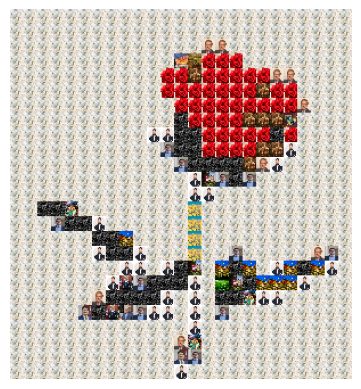

In [14]:

mosaic_size = (25,25)
mosaic_image = create_optimized_mosaic(image_jeorge, images_and_vectors, mosaic_size)
plt.imshow(mosaic_image)
plt.axis('off')
plt.show()

# 5c

In [16]:
def create_optimized_mosaic(target_image, images_and_vectors, mosaic_size=(25, 25), 
                          time_limit=60, lambda_reg=0.1, max_images=None):
    """
    Create an optimized mosaic with a limit on the number of distinct images.
    
    Args:
        target_image: Target image as a numpy array (RGBA or RGB)
        images_and_vectors: List of tuples (PIL_image, average_vector)
        mosaic_size: Mosaic size (rows, columns)
        time_limit: Time limit for optimization in seconds
        lambda_reg: Weight of the regularization term for diversity
        max_images: Maximum number of distinct images allowed (None for no limit)
        
    Returns:
        tuple: (Resulting mosaic image, number of images used, objective value)
    """
    # Convert target image to RGB if it is RGBA
    if target_image.shape[2] == 4:
        target_array = target_image[:, :, :3]
    else:
        target_array = target_image
    
    rows, cols = mosaic_size
    img_height, img_width = target_array.shape[:2]
    cell_height = img_height // rows
    cell_width = img_width // cols
    
    # Check for valid sizes
    if cell_height == 0 or cell_width == 0:
        raise ValueError("The mosaic size is too large for the original image")
    
    # Preprocessing: calculate target vectors for each cell
    target_vectors = []
    for i in range(rows):
        for j in range(cols):
            y_start, y_end = i * cell_height, (i + 1) * cell_height
            x_start, x_end = j * cell_width, (j + 1) * cell_width
            cell = target_array[y_start:y_end, x_start:x_end]
            target_vectors.append(calculate_average_vector(cell))
    
    # Prepare available image data
    image_vectors = [vec for _, vec in images_and_vectors]
    num_images = len(images_and_vectors)
    num_cells = rows * cols
    
    # Create optimization model
    model = gp.Model("PhotoMosaic")
    model.setParam('OutputFlag', 0)
    model.setParam('TimeLimit', time_limit)
    
    # Decision variables
    x = model.addVars(num_cells, num_images, vtype=GRB.BINARY, name="x")  # Assign images to cells
    y = model.addVars(num_images, vtype=GRB.BINARY, name="y")  # Indicator for image usage
    
    # Constraints
    # Each cell must have exactly one image
    for i in range(num_cells):
        model.addConstr(gp.quicksum(x[i, j] for j in range(num_images)) == 1)
    
    # An image is marked as used if it appears in any cell
    for j in range(num_images):
        for i in range(num_cells):
            model.addConstr(y[j] >= x[i, j])
    
    # Limit on the number of distinct images
    if max_images is not None:
        model.addConstr(gp.quicksum(y[j] for j in range(num_images)) <= max_images)
    
    # Objective functionon
    obj = gp.QuadExpr()
    # Part 1: Minimize color distance
    for i in range(num_cells):
        target_vec = target_vectors[i]
        for j in range(num_images):
            img_vec = image_vectors[j]
            diff = target_vec - img_vec
            distance = np.sum(diff**2)
            obj += x[i, j] * distance
    
    # Part 2: Regularization for diversity (now linear instead of quadratic)
    obj += lambda_reg * gp.quicksum(y[j] for j in range(num_images))
    
    model.setObjective(obj, GRB.MINIMIZE)
    
    # Solve the model
    model.optimize()
    
    # Process results Process results
    if model.status in (GRB.OPTIMAL, GRB.TIME_LIMIT, GRB.SUBOPTIMAL):
        mosaic = Image.new('RGB', (cols * cell_width, rows * cell_height))
        resized_images = [
            Image.fromarray(resize_image_optimized_hybrid(np.array(img), (cell_height, cell_width)))
            for img, _ in images_and_vectors
        ]
        
        # Contar imágenes usadas
        images_used = sum(round(y[j].X) for j in range(num_images))
        
        for i in range(num_cells):
            row, col = i // cols, i % cols
            for j in range(num_images):
                if x[i, j].X > 0.5:
                    mosaic.paste(resized_images[j], (col * cell_width, row * cell_height))
                    break
        
        return mosaic, images_used, model.ObjVal
    else:
        raise Exception(f"El modelo no pudo encontrar una solución válida. Estado: {model.status}")


def mosaic_sensitivity_analysis(target_image, images_and_vectors, mosaic_size=(25, 25),
                              max_images_range=None, lambda_values=[0.1], time_limit=30):
    """
    Realiza análisis de sensibilidad variando el número máximo de imágenes permitidas.
    
    Args:
        target_image: Imagen objetivo
        images_and_vectors: Lista de imágenes disponibles
        mosaic_size: Tamaño del mosaico
        max_images_range: Rango de valores K a probar (None para automático)
        lambda_values: Lista de valores lambda a probar
        time_limit: Tiempo límite por optimización
        
    Returns:
        DataFrame con los resultados del análisis
    """
    num_images = len(images_and_vectors)
    if max_images_range is None:
        max_images_range = range(1, min(50, num_images), max(1, min(50, num_images)//10))
    
    results = []
    
    for lambda_reg in lambda_values:
        for K in max_images_range:
            try:
                mosaic, images_used, obj_value = create_optimized_mosaic(
                    target_image,
                    images_and_vectors,
                    mosaic_size=mosaic_size,
                    time_limit=time_limit,
                    lambda_reg=lambda_reg,
                    max_images=K
                )
                
                results.append({
                    'lambda': lambda_reg,
                    'max_images_allowed': K,
                    'images_used': images_used,
                    'objective_value': obj_value,
                    'mosaic': mosaic
                })
                
                print(f"λ={lambda_reg:.2f}, K={K}: Obj={obj_value:.2f}, Used={images_used}")
                
            except Exception as e:
                print(f"Error con λ={lambda_reg:.2f}, K={K}: {str(e)}")
                results.append({
                    'lambda': lambda_reg,
                    'max_images_allowed': K,
                    'images_used': 0,
                    'objective_value': float('nan'),
                    'mosaic': None
                })
    
    return pd.DataFrame(results)

In [17]:
# 1. Definir rango de valores lambda a probar
lambda_values = np.logspace(-3, 1, 10)  # De 0.001 a 10 en escala log

# 2. Definir rango de valores para el número máximo de imágenes permitidas
max_images_range = range(1, 28, 5)  # Probar con 1, 6, 11, 16, 21, 26 imágenes distintas

# 3. Ejecutar análisis de sensibilidad
results = mosaic_sensitivity_analysis(
    target_image=image_jeorge,
    images_and_vectors=images_and_vectors,
    mosaic_size=mosaic_size,
    max_images_range=max_images_range,
    lambda_values=lambda_values,
    time_limit=30
)

# 4. Visualizar resultados
for _, row in results.iterrows():
    print(f"λ={row['lambda']:.3f}, Max Images={row['max_images_allowed']}, "
          f"Images Used={row['images_used']}, Objective={row['objective_value']:.2f}")

# 5. Mostrar los mejores mosaicos
top_results = results.nsmallest(5, 'objective_value')  # Seleccionar los 3 mejores resultados
for i, row in top_results.iterrows():
    plt.figure(figsize=(5, 5))
    plt.imshow(row['mosaic'])
    plt.axis('off')
    plt.title(f"λ={row['lambda']:.3f}, Max Images={row['max_images_allowed']}")
    plt.show()

λ=0.00, K=1: Obj=10465399.65, Used=1
λ=0.00, K=6: Obj=3083529.24, Used=6
λ=0.00, K=11: Obj=3052168.22, Used=11
λ=0.00, K=16: Obj=3050280.07, Used=16
λ=0.00, K=21: Obj=3050145.16, Used=18
λ=0.00, K=26: Obj=3050145.16, Used=18
λ=0.00, K=1: Obj=10465399.65, Used=1
λ=0.00, K=6: Obj=3083529.25, Used=6
λ=0.00, K=11: Obj=3052168.24, Used=11
λ=0.00, K=16: Obj=3050280.10, Used=16
λ=0.00, K=21: Obj=3050145.19, Used=18
λ=0.00, K=26: Obj=3050145.19, Used=18
λ=0.01, K=1: Obj=10465399.66, Used=1
λ=0.01, K=6: Obj=3083529.28, Used=6
λ=0.01, K=11: Obj=3052168.29, Used=11
λ=0.01, K=16: Obj=3050280.17, Used=16
λ=0.01, K=21: Obj=3050145.28, Used=18
λ=0.01, K=26: Obj=3050145.28, Used=18
λ=0.02, K=1: Obj=10465399.67, Used=1
λ=0.02, K=6: Obj=3083529.36, Used=6
λ=0.02, K=11: Obj=3052168.44, Used=11
λ=0.02, K=16: Obj=3050280.40, Used=16
λ=0.02, K=21: Obj=3050145.53, Used=18
λ=0.02, K=26: Obj=3050145.53, Used=18


KeyboardInterrupt: 

In [ ]:
results

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Style configuration
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# 1. Error Evolution by Number of Images
fig1, ax1 = plt.subplots()
lambda_values = results['lambda'].unique()
colors = plt.cm.viridis(np.linspace(0, 1, len(lambda_values)))

for lambda_val, color in zip(lambda_values, colors):
    subset = results[results['lambda'] == lambda_val]
    ax1.plot(subset['images_used'], subset['objective_value'], 
            'o-', color=color, label=f'λ={lambda_val:.4f}')

ax1.set_xlabel('Number of Images Used')
ax1.set_ylabel('Objective Value (Error)')
ax1.set_title('Error Evolution by Number of Images and λ Value')
ax1.legend(title='Lambda value')
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')
plt.tight_layout()
plt.show()

# 2. Pareto Frontier by Lambda Value
fig2, ax2 = plt.subplots()

for lambda_val, color in zip(lambda_values, colors):
    subset = results[results['lambda'] == lambda_val].sort_values('images_used')
    pareto_front = []
    min_error = float('inf')
    
    for _, row in subset.iterrows():
        if row['objective_value'] < min_error:
            min_error = row['objective_value']
            pareto_front.append((row['images_used'], row['objective_value']))
    
    x, y = zip(*pareto_front)
    ax2.plot(x, y, 'o--', color=color, label=f'λ={lambda_val:.4f}')

ax2.set_xlabel('Number of Images Used')
ax2.set_ylabel('Best Achievable Objective Value')
ax2.set_title('Pareto Frontiers by λ Value')
ax2.legend(title='Lambda value')
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log')
plt.tight_layout()
plt.show()

# 3. Percentage Improvement Chart
fig3, ax3 = plt.subplots()

for lambda_val, color in zip(lambda_values, colors):
    subset = results[results['lambda'] == lambda_val].sort_values('images_used')
    baseline = subset['objective_value'].iloc[0]
    improvement = 100 * (baseline - subset['objective_value']) / baseline
    
    ax3.plot(subset['images_used'], improvement, 's-', color=color, label=f'λ={lambda_val:.4f}')

ax3.set_xlabel('Number of Images Used')
ax3.set_ylabel('Relative Improvement (%)')
ax3.set_title('Quality Improvement Percentage by Adding More Images')
ax3.legend(title='Lambda value')
ax3.grid(True, alpha=0.3)
ax3.axhline(y=95, color='red', linestyle='--', alpha=0.5)
ax3.text(1, 96, '95% improvement', color='red')
plt.tight_layout()
plt.show()

# 4. Alternative Heatmap (using pcolor)
fig4, ax4 = plt.subplots(figsize=(10, 6))

# Prepare data for heatmap
lambda_vals = sorted(results['lambda'].unique())
image_counts = sorted(results['images_used'].unique())
error_matrix = np.zeros((len(lambda_vals), len(image_counts)))

for i, l in enumerate(lambda_vals):
    for j, c in enumerate(image_counts):
        mask = (results['lambda'] == l) & (results['images_used'] == c)
        if any(mask):
            error_matrix[i, j] = results.loc[mask, 'objective_value'].values[0]
        else:
            error_matrix[i, j] = np.nan

# Create heatmap
pc = ax4.pcolor(image_counts, lambda_vals, error_matrix, 
               cmap='viridis_r', shading='auto')
fig4.colorbar(pc, ax=ax4, label='Objective Value (Error)')

ax4.set_xlabel('Number of Images Used')
ax4.set_ylabel('Lambda Value')
ax4.set_title('Heatmap: Error by λ and Number of Images')
ax4.set_yscale('log')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()